In [1]:
import matplotlib.pyplot as plt
import numpy as np

import wandb

# Dataset to model mapping
DATASET_MODEL_MAP = {"CIFAR10": "CIFAR-10 - ResNet18"}

In [ ]:
api = wandb.Api(timeout=120)

In [ ]:
# Collect communication cost data from the sweep
# sweep_id = "ICDCS/FedHAR/9uw01ajn"

# sweep_id = "ICDCS/FedHAR/7sim29aw"

sweep_id = "ICDCS/FedCIFAR10/gbt8maur"

print(f"Fetching sweep: {sweep_id}")
sweep = api.sweep(sweep_id)
runs = sweep.runs

# Dictionary to store run data
run_comm_costs = {}

for run in runs:
    print(f"\nProcessing run: {run.name}")
    if "2" not in run.name:
        continue

    # Initialize data structures
    rounds = []
    round_totals = {}  # {round_num: total_cost} - to accumulate costs per round across clusters
    cluster_costs = {}  # {cluster_id: [costs per round]}
    cluster_model_sizes = {}  # {cluster_id: set of unique model sizes in bits}

    # Build list of keys to fetch for up to 16 groups
    group_cost_keys = [f"CommCost/Group_{i}/Total/Combined" for i in range(16)]
    group_size_keys = [f"CommCost/Group_{i}/ModelSize/Bits" for i in range(16)]

    for i, (key_cost, key_size) in enumerate(zip(group_cost_keys, group_size_keys)):
        for row in run.scan_history(keys=["round", key_cost, key_size]):
            round_num = row["round"]
            if round_num is None:
                continue

            if round_num not in rounds:
                rounds.append(round_num)

            # Collect costs and model sizes for each cluster (up to 16)
            cost_val = row[key_cost]

            if cost_val is not None and cost_val == cost_val:  # Check for not None and not NaN
                # Accumulate cost for this round
                if round_num not in round_totals:
                    round_totals[round_num] = 0
                round_totals[round_num] += cost_val

                if i not in cluster_costs:
                    cluster_costs[i] = []
                cluster_costs[i].append(cost_val)
            else:
                if i not in cluster_costs:
                    cluster_costs[i] = []
                cluster_costs[i].append(0)

            # Collect model size in bits for each cluster

            model_size_val = row[key_size]
            if model_size_val is not None and model_size_val == model_size_val:
                if i not in cluster_model_sizes:
                    cluster_model_sizes[i] = set()
                cluster_model_sizes[i].add(model_size_val)

    # Convert round_totals dict to list ordered by rounds
    total_costs_per_round = [round_totals.get(r, 0) for r in sorted(rounds)]

    # Calculate average pruning ratio for this run
    pruning_ratios = []
    for cluster_id, sizes in cluster_model_sizes.items():
        unique_sizes = sorted(sizes)
        # Ratio of smaller to larger model size
        ratio = unique_sizes[0] / unique_sizes[-1]
        pruning_ratios.append(ratio)
        print(f"  Cluster {cluster_id}: sizes={unique_sizes}, ratio={ratio:.4f}")

    avg_ratio = np.mean(pruning_ratios)
    avg_pruning_ratio = 1 - avg_ratio
    print(f"  Average pruning ratio: {avg_pruning_ratio:.4f}")

    # Store the data
    run_comm_costs[run.name] = {
        "rounds": sorted(rounds),
        "total_costs": total_costs_per_round,
        "cluster_costs": cluster_costs,
        "cluster_model_sizes": {k: sorted(v) for k, v in cluster_model_sizes.items()},
        "avg_pruning_ratio": avg_pruning_ratio,
    }

    print(f"  Collected {len(rounds)} rounds")
    print(f"  Total clusters: {len(cluster_costs)}")

print(f"\nCollected data from {len(run_comm_costs)} runs")

## New Model

In [ ]:
# parameters
total_clients = 100
num_clients = 10
z_card = np.array([total_clients], dtype=float)

# advanced params
gamma = 3  # amout of consolidation steps
rho = 0.5  # portion of cluster that tells us how many votes we need

# size in bits
model_size = 11539939.0 * 32
prune_ratio = np.array([0.7771 / gamma])  # 0.7771


def q(j):
    return 1.0 - (j * prune_ratio)


# need to see based on the votes
p = np.array([0.1875])


p_round = (num_clients / total_clients) * p
s_z = (num_clients * z_card) / total_clients


v_req = np.maximum(1, (rho * z_card))
delta_t = v_req / (s_z * p)


def t_j(j):
    return j * delta_t


def d(t, j, gamma):
    if j >= gamma:
        # Final stage (j = gamma): no upper bound, continues indefinitely
        return np.maximum(0, t - t_j(j))
    else:
        # Intermediate stages (j < gamma): bounded by t_j(j+1)
        return np.maximum(0, np.minimum(t, t_j(j + 1)) - t_j(j))


def g(t):
    return 2 * s_z * model_size * (sum([q(j) * d(t, j, gamma) for j in range(0, gamma + 1)]))

## Plot

In [2]:
# Test and plot the cost model over time
print("Testing cost_model function...")
print(f"s_z values: {s_z}")
print(f"model_size: {model_size}")

# Test with a few sample values
test_times = [0, 50, 100, 150, 200]
print("\nTest outputs:")
for t in test_times:
    try:
        cost = g(t + 1)
        print(f"  t={t}: cost={cost}")
    except Exception as e:
        print(f"  t={t}: ERROR - {e}")

# Create time array for plotting the model
t_values = np.linspace(0, 500, 500)
model_costs = np.array([g(t + 1) for t in t_values])

# Convert model costs to MB (model already returns cumulative values)
model_costs_mb = model_costs / (8 * 1024 * 1024)

# Create figure with subplots: one for total cost, one for per-cluster costs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Total Communication Cost (CUMULATIVE)
ax1.set_xlabel("Round", fontsize=12)
ax1.set_ylabel("Cumulative Communication Cost (MB)", fontsize=12)
ax1.set_title("Cumulative Total Communication Cost: Model vs Actual", fontsize=14)

# Plot model cumulative total cost (sum across groups) - already cumulative from model
total_model_cost = model_costs_mb.sum(axis=1)
ax1.plot(t_values, total_model_cost, label="Cost Model (Total)", linewidth=2, linestyle="--", color="black")

# Plot actual run total costs (CUMULATIVE)
for run_name, run_data in run_comm_costs.items():
    rounds = run_data["rounds"]
    total_costs = np.cumsum(run_data["total_costs"]) / (8 * 1024 * 1024)  # Cumulative and convert to MB
    ax1.plot(rounds, total_costs, label=f"{run_name} (Actual)", linewidth=2, marker="o", markersize=3)

ax1.legend(loc="best", fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2: Per-Cluster Communication Cost (CUMULATIVE)
ax2.set_xlabel("Round", fontsize=12)
ax2.set_ylabel("Cumulative Communication Cost (MB)", fontsize=12)
ax2.set_title("Cumulative Per-Cluster Communication Cost: Model vs Actual", fontsize=14)

# Plot model cumulative costs per group - already cumulative from model
for i in range(len(z_card)):
    ax2.plot(t_values, model_costs_mb[:, i], label=f"Model Cluster {i}", linewidth=2, linestyle="--")

# Plot actual cluster costs from runs (CUMULATIVE)
colors = plt.cm.tab10(np.linspace(0, 1, 10))
for run_name, run_data in run_comm_costs.items():
    rounds = run_data["rounds"]
    cluster_costs = run_data["cluster_costs"]

    for cluster_id, costs in cluster_costs.items():
        cumulative_costs = np.cumsum(costs) / (8 * 1024 * 1024)  # Cumulative and convert to MB
        if (cumulative_costs == 0).all():
            continue
        ax2.plot(
            rounds,
            cumulative_costs[:500],
            label=f"{run_name} Cluster {cluster_id}",
            linewidth=1.5,
            marker=".",
            markersize=2,
            color=colors[cluster_id % 10],
            alpha=0.7,
        )

ax2.legend(loc="best", fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nPlot generated successfully!")

Testing cost_model function...


NameError: name 's_z' is not defined

Sweep: ICDCS/FedCIFAR10/yrqvonkv
Total runs: 5
Evaluated runs: 5
Skipped runs: 0
Max rounds analyzed: 100
OK   ICDCS/FedCIFAR10/f0ax9at5 | RMSE(g/s)=6.752e+09/1.994e+09 | rRMSE(g/s)=5.37%/1.59% | MAPE(g/s)=4.41%/1.41% | sMAPE(g/s)=4.54%/1.42% | R2(g/s)=0.9858/0.9988 | Bias%(g/s)=-4.41%/-1.41% | p=[0.4545, 0.3333, 0.6500]
    segment_0: RMSE=0.000e+00, rRMSE=0.00%, MAPE=0.00%, sMAPE=0.00%, R2=1.0000, Bias%=0.00%, FinalBias%=0.00%
    segment_1: RMSE=1.454e+09, rRMSE=2.21%, MAPE=1.80%, sMAPE=1.82%, R2=0.9886, Bias%=-1.80%, FinalBias%=-2.73%
    segment_2: RMSE=2.209e+09, rRMSE=2.25%, MAPE=2.26%, sMAPE=2.29%, R2=0.8170, Bias%=-2.26%, FinalBias%=-2.10%
    segment_3: RMSE=2.225e+09, rRMSE=1.39%, MAPE=1.45%, sMAPE=1.46%, R2=0.9947, Bias%=-1.45%, FinalBias%=-1.05%
OK   ICDCS/FedCIFAR10/i40gnw6p | RMSE(g/s)=1.092e+10/6.834e+09 | rRMSE(g/s)=4.63%/2.90% | MAPE(g/s)=4.17%/2.63% | sMAPE(g/s)=4.28%/2.67% | R2(g/s)=0.9896/0.9959 | Bias%(g/s)=-4.17%/-2.63% | p=[0.5889, 0.5000, 0.7571]
    segment_0:

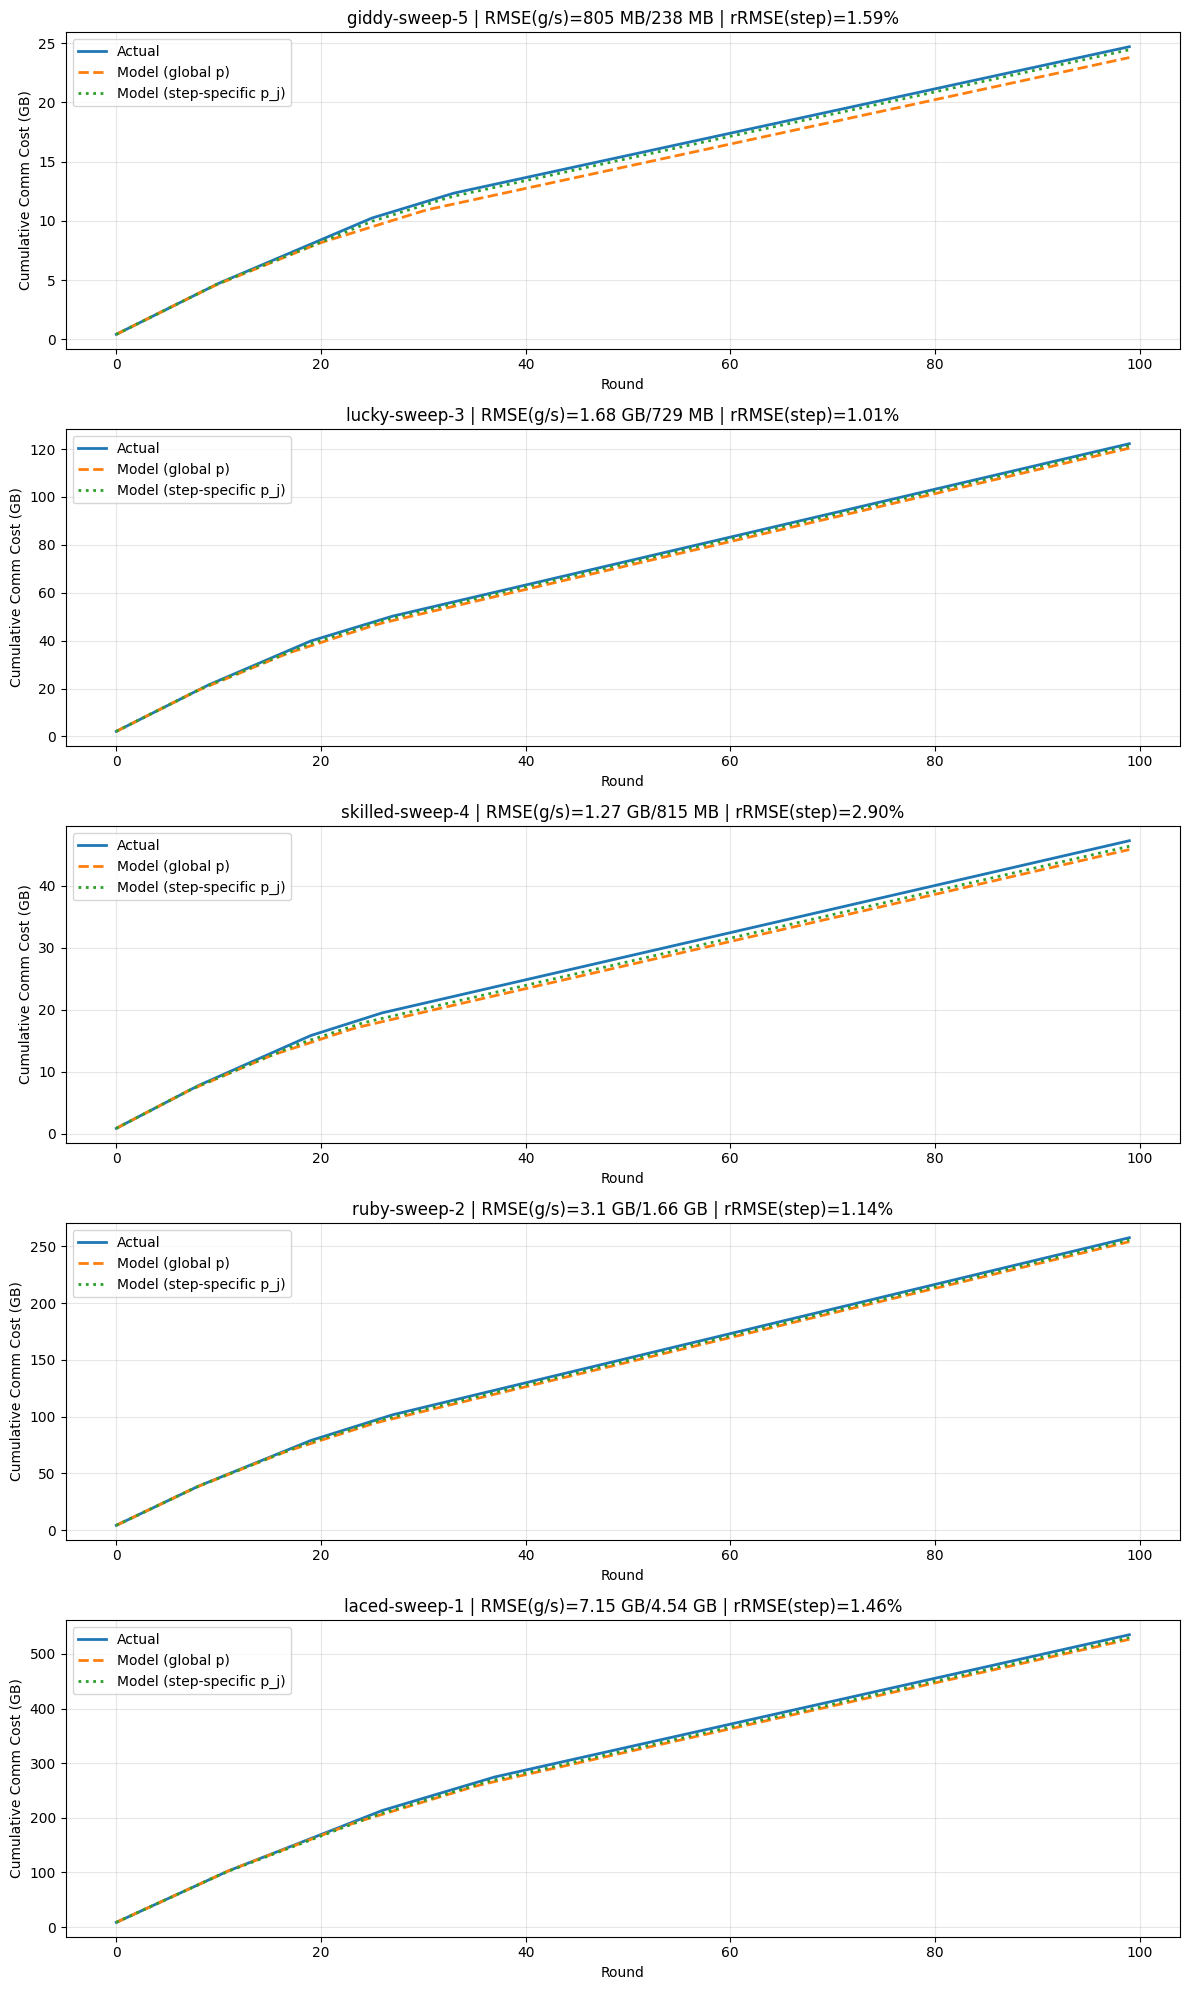

Global-probability model metrics


,total_clients,segment,mae,mae_unit,mape_percent,smape_percent,r2,mean_bias_percent,final_bias_percent
0,50,overall,724.547415,MB,4.413898,4.535773,0.985797,-4.413898,-3.704973
1,50,segment_0,4.279635,MB,0.088379,0.088811,0.999896,-0.088379,-0.972172
2,50,segment_1,286.962986,MB,3.303159,3.376346,0.951870,-3.303159,-7.233809
3,50,segment_2,785.682680,MB,6.712150,6.946022,-0.641558,-6.712150,-7.411489
4,50,segment_3,936.632717,MB,5.108683,5.248288,0.934124,-5.108683,-3.704973
5,100,overall,1.176172,GB,4.173983,4.280102,0.989611,-4.173983,-3.018407
6,100,segment_0,0.015537,GB,0.200782,0.202613,0.999559,-0.200782,-1.807039
7,100,segment_1,0.477467,GB,3.649490,3.731338,0.941037,-3.649490,-7.072264
8,100,segment_2,1.165535,GB,6.497210,6.716473,-0.252067,-6.497210,-7.316783
9,100,segment_3,1.425568,GB,4.520087,4.631872,0.968315,-4.520087,-3.018407


Step-probability model metrics


,total_clients,segment,mae,mae_unit,mape_percent,smape_percent,r2,mean_bias_percent,final_bias_percent
0,50,overall,218.993295,MB,1.405136,1.417296,0.998762,-1.405136,-1.049247
1,50,segment_0,0.000000,MB,0.000000,0.000000,1.000000,0.000000,0.000000
2,50,segment_1,152.495117,MB,1.796559,1.815459,0.988642,-1.796559,-2.726189
3,50,segment_2,263.141466,MB,2.259743,2.285779,0.816974,-2.259743,-2.098932
4,50,segment_3,265.254106,MB,1.446778,1.457750,0.994717,-1.446778,-1.049247
5,100,overall,755.463455,MB,2.626518,2.667686,0.995928,-2.626518,-1.893584
6,100,segment_0,9.268465,MB,0.116969,0.117588,0.999850,-0.116969,-1.052723
7,100,segment_1,325.300297,MB,2.471172,2.505547,0.976367,-2.471172,-4.439030
8,100,segment_2,718.875944,MB,3.916186,3.995147,0.544159,-3.916186,-4.590151
9,100,segment_3,915.787595,MB,2.835656,2.879222,0.987530,-2.835656,-1.893584


LaTeX tables saved to: plots/costmodel_metrics_global.tex, plots/costmodel_metrics_step.tex


In [3]:
import importlib
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import comask.analysis.cost_model_validation as cmv

importlib.reload(cmv)


from comask.analysis.cost_model_validation import (
    build_summary_rows,
    validate_sweep_cost_model,
)

SWEEP_PATH = "ICDCS/FedCIFAR10/yrqvonkv"

GAMMA = 3

RHO = 0.5
MAX_ROUNDS = 100  # Set to None to use all available rounds


BYTE_UNITS = [
    ("GB", 1024**3),
    ("MB", 1024**2),
    ("KB", 1024),
    ("B", 1),
]


def _best_byte_unit(abs_bytes):
    for unit, factor in BYTE_UNITS:
        if abs_bytes >= factor:
            return unit, factor
    return "B", 1


def _bits_to_best_unit_scalar(value_bits):
    if value_bits is None:
        return np.nan, ""

    value_bits = float(value_bits)
    if not np.isfinite(value_bits):
        return np.nan, ""

    value_bytes = value_bits / 8.0
    unit, factor = _best_byte_unit(abs(value_bytes))
    return value_bytes / factor, unit


def _select_best_unit_from_bits(values_bits):
    values = np.array(values_bits, dtype=float)
    finite_values = values[np.isfinite(values)]

    if finite_values.size == 0:
        return "B", 1

    max_abs_bytes = float(np.max(np.abs(finite_values))) / 8.0
    return _best_byte_unit(max_abs_bytes)


def _bits_array_to_unit(values_bits, unit_factor):
    return np.array(values_bits, dtype=float) / (8.0 * float(unit_factor))


def _convert_mae_bits_to_human(df, group_col="total_clients"):
    if df.empty:
        return df

    df = df.copy()
    mae_bits = pd.to_numeric(df["mae"], errors="coerce")

    mae_scaled = pd.Series(np.nan, index=df.index, dtype=float)
    mae_units = pd.Series("", index=df.index, dtype=object)

    if group_col in df.columns:
        group_iterable = df.groupby(group_col, sort=False).groups.values()
    else:
        group_iterable = [df.index]

    for group_index in group_iterable:
        group_bits = mae_bits.loc[group_index].to_numpy(dtype=float)
        unit, factor = _select_best_unit_from_bits(group_bits)
        mae_scaled.loc[group_index] = group_bits / (8.0 * float(factor))
        mae_units.loc[group_index] = unit

    df["mae"] = mae_scaled
    mae_col_index = df.columns.get_loc("mae")
    df.insert(mae_col_index + 1, "mae_unit", mae_units)
    return df


validation = validate_sweep_cost_model(
    sweep_path=SWEEP_PATH,
    gamma=GAMMA,
    rho=RHO,
    group_id=0,
    proposal_cluster_id=0,
    max_rounds=MAX_ROUNDS,
)


summary_rows = build_summary_rows(validation)

evaluated = [result for result in validation.results if result.status == "evaluated"]

skipped = [result for result in validation.results if result.status != "evaluated"]


print(f"Sweep: {SWEEP_PATH}")

print(f"Total runs: {len(validation.results)}")

print(f"Evaluated runs: {len(evaluated)}")

print(f"Skipped runs: {len(skipped)}")
print(f"Max rounds analyzed: {MAX_ROUNDS if MAX_ROUNDS is not None else 'all'}")


for row in summary_rows:
    status = row["status"]

    run_path = row["run_path"]

    if status != "evaluated":
        print(f"SKIP {run_path} -> {row['skip_reason']}")

        continue

    print(
        f"OK   {run_path} | "
        f"RMSE(g/s)={row['rmse_global']:.3e}/{row['rmse_step']:.3e} | "
        f"rRMSE(g/s)={row['relative_rmse_global']:.2%}/{row['relative_rmse_step']:.2%} | "
        f"MAPE(g/s)={row['mape_percent_global']:.2f}%/{row['mape_percent_step']:.2f}% | "
        f"sMAPE(g/s)={row['smape_percent_global']:.2f}%/{row['smape_percent_step']:.2f}% | "
        f"R2(g/s)={row['r2_global']:.4f}/{row['r2_step']:.4f} | "
        f"Bias%(g/s)={row['mean_bias_percent_global']:.2f}%/{row['mean_bias_percent_step']:.2f}% | "
        f"p=[{row['p_step_0']:.4f}, {row['p_step_1']:.4f}, {row['p_step_2']:.4f}]"
    )

    segments_step = row.get("segments_step", {}) or {}

    for segment_name, segment_metrics in segments_step.items():
        print(
            f"    {segment_name}: "
            f"RMSE={segment_metrics.get('rmse', np.nan):.3e}, "
            f"rRMSE={segment_metrics.get('relative_rmse', np.nan):.2%}, "
            f"MAPE={segment_metrics.get('mape_percent', np.nan):.2f}%, "
            f"sMAPE={segment_metrics.get('smape_percent', np.nan):.2f}%, "
            f"R2={segment_metrics.get('r2', np.nan):.4f}, "
            f"Bias%={segment_metrics.get('mean_bias_percent', np.nan):.2f}%, "
            f"FinalBias%={segment_metrics.get('final_bias_percent', np.nan):.2f}%"
        )


if evaluated:
    max_plots = len(evaluated)

    ranked = sorted(
        evaluated,
        key=lambda result: result.metrics_step.get("rmse", np.inf),
    )[:max_plots]

    fig, axes = plt.subplots(max_plots, 1, figsize=(12, 4 * max_plots), sharex=False)

    if max_plots == 1:
        axes = [axes]

    for axis, result in zip(axes, ranked):
        rounds = np.array(result.rounds, dtype=float)

        actual_bits = np.array(result.actual_cumulative_cost, dtype=float)
        pred_global_bits = np.array(result.predicted_cumulative_global, dtype=float)
        pred_step_bits = np.array(result.predicted_cumulative_step, dtype=float)

        combined_bits = np.concatenate([actual_bits, pred_global_bits, pred_step_bits])
        y_unit, y_factor = _select_best_unit_from_bits(combined_bits)

        actual_scaled = _bits_array_to_unit(actual_bits, y_factor)
        pred_global_scaled = _bits_array_to_unit(pred_global_bits, y_factor)
        pred_step_scaled = _bits_array_to_unit(pred_step_bits, y_factor)

        axis.plot(rounds, actual_scaled, label="Actual", linewidth=2)

        axis.plot(rounds, pred_global_scaled, label="Model (global p)", linestyle="--", linewidth=2)

        axis.plot(rounds, pred_step_scaled, label="Model (step-specific p_j)", linestyle=":", linewidth=2)

        rmse_global_value, rmse_global_unit = _bits_to_best_unit_scalar(result.metrics_global["rmse"])
        rmse_step_value, rmse_step_unit = _bits_to_best_unit_scalar(result.metrics_step["rmse"])

        axis.set_title(
            f"{result.run_name} | RMSE(g/s)={rmse_global_value:.3g} {rmse_global_unit}/{rmse_step_value:.3g} {rmse_step_unit} | "
            f"rRMSE(step)={result.metrics_step.get('relative_rmse', np.nan):.2%}"
        )

        axis.set_xlabel("Round")

        axis.set_ylabel(f"Cumulative Comm Cost ({y_unit})")

        axis.grid(True, alpha=0.3)

        axis.legend(loc="best")

    plt.tight_layout()

    plt.show()

else:
    print("No runs were evaluated. Check skip reasons above.")


# Build two LONG dataframes (global model and step model) with one overall row + one row per segment

evaluated_rows = [row for row in summary_rows if row["status"] == "evaluated"]


global_records = []
step_records = []

for row in evaluated_rows:
    base = {
        "total_clients": row["total_clients"],
    }

    overall_common = {
        **base,
        "segment": "overall",
    }

    global_records.append(
        {
            **overall_common,
            "mae": row["mae_global"],
            "mape_percent": row["mape_percent_global"],
            "smape_percent": row["smape_percent_global"],
            "r2": row["r2_global"],
            "mean_bias_percent": row["mean_bias_percent_global"],
            "final_bias_percent": row["final_bias_percent_global"],
        }
    )

    step_records.append(
        {
            **overall_common,
            "mae": row["mae_step"],
            "mape_percent": row["mape_percent_step"],
            "smape_percent": row["smape_percent_step"],
            "r2": row["r2_step"],
            "mean_bias_percent": row["mean_bias_percent_step"],
            "final_bias_percent": row["final_bias_percent_step"],
        }
    )

    segments_global = row.get("segments_global", {}) or {}
    segments_step = row.get("segments_step", {}) or {}

    for segment_idx in range(GAMMA + 1):
        segment_key = f"segment_{segment_idx}"

        global_metrics = segments_global.get(segment_key, {})
        step_metrics = segments_step.get(segment_key, {})

        segment_common = {
            **base,
            "segment": segment_key,
        }

        global_records.append(
            {
                **segment_common,
                "mae": global_metrics.get("mae", np.nan),
                "mape_percent": global_metrics.get("mape_percent", np.nan),
                "smape_percent": global_metrics.get("smape_percent", np.nan),
                "r2": global_metrics.get("r2", np.nan),
                "mean_bias_percent": global_metrics.get("mean_bias_percent", np.nan),
                "final_bias_percent": global_metrics.get("final_bias_percent", np.nan),
            }
        )

        step_records.append(
            {
                **segment_common,
                "mae": step_metrics.get("mae", np.nan),
                "mape_percent": step_metrics.get("mape_percent", np.nan),
                "smape_percent": step_metrics.get("smape_percent", np.nan),
                "r2": step_metrics.get("r2", np.nan),
                "mean_bias_percent": step_metrics.get("mean_bias_percent", np.nan),
                "final_bias_percent": step_metrics.get("final_bias_percent", np.nan),
            }
        )


def _segment_order(segment_value):
    if segment_value == "overall":
        return -1
    return int(str(segment_value).split("_")[1])


def _sort_metrics_df(df):
    if df.empty:
        return df
    df = df.copy()
    df["segment_order"] = df["segment"].apply(_segment_order)
    return df.sort_values(["total_clients", "segment_order"]).drop(columns=["segment_order"]).reset_index(drop=True)


metrics_global_df = _convert_mae_bits_to_human(_sort_metrics_df(pd.DataFrame(global_records)))
metrics_step_df = _convert_mae_bits_to_human(_sort_metrics_df(pd.DataFrame(step_records)))

print("Global-probability model metrics")
display(metrics_global_df)

print("Step-probability model metrics")
display(metrics_step_df)


os.makedirs("plots", exist_ok=True)

latex_path_global = "plots/costmodel_metrics_global.tex"
latex_path_step = "plots/costmodel_metrics_step.tex"

latex_table_global = metrics_global_df.to_latex(index=False, float_format=lambda x: f"{x:.4g}")
latex_table_step = metrics_step_df.to_latex(index=False, float_format=lambda x: f"{x:.4g}")

with open(latex_path_global, "w", encoding="utf-8") as file_handle:
    file_handle.write(latex_table_global)

with open(latex_path_step, "w", encoding="utf-8") as file_handle:
    file_handle.write(latex_table_step)

print(f"LaTeX tables saved to: {latex_path_global}, {latex_path_step}")

In [4]:
# Consolidation-timing precision analysis (separate cell)
if "validation" not in globals():
    raise RuntimeError("Run the previous analysis cell first to populate `validation`.")

timing_rows = cmv.build_consolidation_timing_rows(validation)
timing_df = pd.DataFrame(timing_rows)

if not timing_df.empty:
    timing_df["model"] = pd.Categorical(
        timing_df["model"],
        categories=["global_probability", "step_probability"],
        ordered=True,
    )
    timing_df["aggregation"] = pd.Categorical(
        timing_df["aggregation"],
        categories=["micro", "macro"],
        ordered=True,
    )
    timing_df = timing_df.sort_values(["model", "aggregation"]).reset_index(drop=True)

print("Consolidation timing precision (round error)")
display(timing_df)

for _, timing_row in timing_df.iterrows():
    print(
        f"{timing_row['model']} | {timing_row['aggregation']} | "
        f"MAE={timing_row['mae_rounds']:.3g} rounds | "
        f"RMSE={timing_row['rmse_rounds']:.3g} rounds | "
        f"Bias={timing_row['mean_bias_rounds']:.3g} rounds | "
        f"runs={int(timing_row['runs_count'])}, events={int(timing_row['events_count'])}"
    )

os.makedirs("plots", exist_ok=True)
latex_path_timing = "plots/costmodel_timing_precision.tex"
latex_table_timing = timing_df.to_latex(index=False, float_format=lambda value: f"{value:.4g}")

with open(latex_path_timing, "w", encoding="utf-8") as file_handle:
    file_handle.write(latex_table_timing)

print(f"Timing precision LaTeX table saved to: {latex_path_timing}")

Consolidation timing precision (round error)


,model,aggregation,mae_rounds,rmse_rounds,mean_bias_rounds,runs_count,events_count
0,global_probability,micro,2.926095,3.218767,-2.926095,5,15
1,global_probability,macro,2.926095,3.149588,-2.926095,5,15
2,step_probability,micro,1.677744,1.761666,-1.677744,5,15
3,step_probability,macro,1.677744,1.715037,-1.677744,5,15


global_probability | micro | MAE=2.93 rounds | RMSE=3.22 rounds | Bias=-2.93 rounds | runs=5, events=15
global_probability | macro | MAE=2.93 rounds | RMSE=3.15 rounds | Bias=-2.93 rounds | runs=5, events=15
step_probability | micro | MAE=1.68 rounds | RMSE=1.76 rounds | Bias=-1.68 rounds | runs=5, events=15
step_probability | macro | MAE=1.68 rounds | RMSE=1.72 rounds | Bias=-1.68 rounds | runs=5, events=15
Timing precision LaTeX table saved to: plots/costmodel_timing_precision.tex


In [15]:
# Fixed-pruning analysis: force pruning ratio to 0.1 per step (0.3 total for GAMMA=3)
if "validation" not in globals():
    raise RuntimeError("Run Cell 8 first to populate `validation`.")

FIXED_PRUNE_RATIO_PER_STEP = 0.1
FIXED_PRUNE_RATIO_TOTAL = FIXED_PRUNE_RATIO_PER_STEP * GAMMA

print(
    f"Running fixed-pruning analysis with per-step={FIXED_PRUNE_RATIO_PER_STEP:.3f}, "
    f"total={FIXED_PRUNE_RATIO_TOTAL:.3f}"
)

fixed_prune_rows = []

for result in validation.results:
    if result.status != "evaluated":
        continue

    if not result.rounds:
        continue

    rounds = [int(round_value) for round_value in result.rounds if round_value < MAX_ROUNDS]
    print(rounds)
    actual_cumulative = np.array(result.actual_cumulative_cost, dtype=float)

    predicted_global_fixed = cmv._predict_cumulative_cost(
        rounds=rounds,
        total_clients=int(result.total_clients),
        clients_per_round=int(result.clients_per_round),
        initial_model_size_bits=float(result.initial_model_size_bits),
        prune_ratio=FIXED_PRUNE_RATIO_TOTAL,
        gamma=GAMMA,
        rho=RHO,
        global_p=float(result.global_probability),
    )

    predicted_step_fixed = cmv._predict_cumulative_cost(
        rounds=rounds,
        total_clients=int(result.total_clients),
        clients_per_round=int(result.clients_per_round),
        initial_model_size_bits=float(result.initial_model_size_bits),
        prune_ratio=FIXED_PRUNE_RATIO_TOTAL,
        gamma=GAMMA,
        rho=RHO,
        p_steps=[float(p_value) for p_value in result.step_probabilities],
    )

    segment_indices = cmv._build_segment_indices(rounds, result.drop_rounds)

    metrics_global_fixed = cmv._compute_metrics(
        actual_cumulative,
        predicted_global_fixed,
        segment_indices=segment_indices,
        segment_count=GAMMA + 1,
    )
    metrics_step_fixed = cmv._compute_metrics(
        actual_cumulative,
        predicted_step_fixed,
        segment_indices=segment_indices,
        segment_count=GAMMA + 1,
    )

    fixed_prune_rows.append(
        {
            # "run_path": result.run_path,
            "total_clients": result.total_clients,
            "model": "global_probability",
            # "fixed_prune_ratio_per_step": FIXED_PRUNE_RATIO_PER_STEP,
            # "fixed_prune_ratio_total": FIXED_PRUNE_RATIO_TOTAL,
            "data_prune_ratio_total": result.prune_ratio,
            "mae": metrics_global_fixed.get("mae"),
            # "rmse": metrics_global_fixed.get("rmse"),
            # "relative_rmse": metrics_global_fixed.get("relative_rmse"),
            "mape_percent": metrics_global_fixed.get("mape_percent"),
            "smape_percent": metrics_global_fixed.get("smape_percent"),
            "r2": metrics_global_fixed.get("r2"),
            # "mean_bias_percent": metrics_global_fixed.get("mean_bias_percent"),
            "final_bias_percent": metrics_global_fixed.get("final_bias_percent"),
        }
    )

    fixed_prune_rows.append(
        {
            # "run_path": result.run_path,
            "total_clients": result.total_clients,
            "model": "step_probability",
            # "fixed_prune_ratio_per_step": FIXED_PRUNE_RATIO_PER_STEP,
            # "fixed_prune_ratio_total": FIXED_PRUNE_RATIO_TOTAL,
            "data_prune_ratio_total": result.prune_ratio,
            "mae": metrics_step_fixed.get("mae"),
            # "rmse": metrics_step_fixed.get("rmse"),
            # "relative_rmse": metrics_step_fixed.get("relative_rmse"),
            "mape_percent": metrics_step_fixed.get("mape_percent"),
            "smape_percent": metrics_step_fixed.get("smape_percent"),
            "r2": metrics_step_fixed.get("r2"),
            # "mean_bias_percent": metrics_step_fixed.get("mean_bias_percent"),
            "final_bias_percent": metrics_step_fixed.get("final_bias_percent"),
        }
    )

fixed_prune_df = pd.DataFrame(fixed_prune_rows)

if fixed_prune_df.empty:
    print("No evaluated runs available for fixed-pruning analysis.")
else:
    fixed_prune_df = fixed_prune_df.sort_values(["total_clients", "model"]).reset_index(drop=True)

    # Keep MAE human-readable using the same conversion helper from Cell 8 if available.
    if "_convert_mae_bits_to_human" in globals():
        fixed_prune_df = _convert_mae_bits_to_human(fixed_prune_df, group_col="total_clients")

    print("Fixed-pruning cost-model metrics")
    display(fixed_prune_df)

    os.makedirs("plots", exist_ok=True)
    latex_path_fixed_prune = "plots/costmodel_metrics_fixed_prune.tex"
    latex_table_fixed_prune = fixed_prune_df.to_latex(index=False, float_format=lambda value: f"{value:.4g}")

    with open(latex_path_fixed_prune, "w", encoding="utf-8") as file_handle:
        file_handle.write(latex_table_fixed_prune)

    print(f"Fixed-pruning LaTeX table saved to: {latex_path_fixed_prune}")

Running fixed-pruning analysis with per-step=0.100, total=0.300
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40,

,total_clients,model,data_prune_ratio_total,mae,mae_unit,mape_percent,smape_percent,r2,final_bias_percent
0,50,global_probability,0.564852,2.944688,GB,15.054222,13.441883,0.635183,32.791921
1,50,step_probability,0.564852,3.206311,GB,16.639894,14.783174,0.586292,34.202411
2,100,global_probability,0.557943,6.745535,GB,18.837404,16.563001,0.502823,36.308244
3,100,step_probability,0.557943,6.980011,GB,19.653938,17.244852,0.477656,36.913049
4,250,global_probability,0.534780,15.852258,GB,17.323798,15.415528,0.601041,32.445729
5,250,step_probability,0.534780,16.353547,GB,18.007774,15.993878,0.582453,32.944056
6,500,global_probability,0.496195,26.369980,GB,13.896960,12.661831,0.757911,25.621954
7,500,step_probability,0.496195,27.163889,GB,14.418787,13.116387,0.747023,26.001706
8,1000,global_probability,0.511531,47.402443,GB,11.410914,10.490337,0.808332,24.145867
9,1000,step_probability,0.511531,48.690598,GB,11.743561,10.777335,0.799884,24.498228


Fixed-pruning LaTeX table saved to: plots/costmodel_metrics_fixed_prune.tex
